In [2]:
import sys
import pickle
import numpy as np
import pandas as pd
import networkx as nx

# Clone/download the authors' repository first
sys.path.insert(0, "src")

# Important for unpickling their custom GRN class
from grn import grn

with open("../graph.647 (1).gpickle", "rb") as f:
    G = pickle.load(f)

beta = np.asarray(G.beta)

print(beta.shape)
print(G.number_of_nodes())
print(G.number_of_edges())
print(np.count_nonzero(beta))

(2000, 2000)
2000
6945
6846


In [3]:
from joblib import Parallel, delayed
from tqdm import tqdm

In [4]:
print("baseline:", hasattr(G, "rna"))
print("single KOs:", hasattr(G, "ko"))

baseline: True
single KOs: True


In [5]:
G.ko

array([[-3.3713575e-02,  2.1886531e-02, -6.1485018e-03, ...,
        -3.0693322e-05,  3.1633109e-03,  1.5994359e-03],
       [-2.6777172e-01, -5.3806227e-01,  3.5516325e-01, ...,
         7.1071486e-06, -2.9521230e-01,  2.0572815e-04],
       [ 6.8455410e-01, -7.4531273e-03, -1.8326247e-01, ...,
         1.7087116e-04, -1.0563799e-03, -9.0768345e-04],
       ...,
       [-1.6379531e-04, -2.4359309e-05,  4.6555351e-06, ...,
         2.4932195e-05,  5.3960692e-05, -6.1847037e-05],
       [-5.5595028e-04, -5.5911591e-05,  4.6525300e-05, ...,
         4.1232655e-05,  4.5008339e-05, -1.1412248e-04],
       [-1.8482271e-04,  8.3972482e-05, -2.6481322e-05, ...,
         1.2267290e-05, -4.3195385e-05, -1.6009380e-07]],
      shape=(2000, 2000), dtype=float32)

In [6]:
from itertools import combinations

rng = np.random.default_rng(1)

baseline = np.asarray(G.rna).reshape(-1)

# Avoid essentially unexpressed genes
eligible = np.where(baseline > G.s)[0]

targets = rng.choice(eligible, size=100, replace=False)

all_pairs = np.array(list(combinations(targets, 2)))
pair_idx = rng.choice(len(all_pairs), size=124, replace=False)
pairs = all_pairs[pair_idx]

pairs.shape

(124, 2)

In [7]:
readout_genes = np.argsort(baseline)[-1000:]

In [9]:
def run_double_ko(pair):
    a, b = pair
    result = G.ko_nodes([a, b], stats=("logfc",))
    return result["logfc"][readout_genes]

double_results = Parallel(
    n_jobs=4,
    verbose=10,
    prefer="processes"
)(
    delayed(run_double_ko)(pair)
    for pair in pairs
)

double_results = np.asarray(double_results)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  5.2min
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  7.9min
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed: 12.6min
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed: 17.0min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed: 21.5min
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed: 26.9min
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed: 32.3min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed: 38.6min
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed: 46.0min
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed: 53.9min
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed: 61.7min
[Parallel(n_jobs=4)]: Done 124 out of 124 | elapsed: 73.6min finished


In [10]:


pairs_arr = np.asarray(pairs, dtype=int)
readout_genes_arr = np.asarray(readout_genes, dtype=int)

np.savez_compressed(
    "../results/grn647_double_ko_results.npz",
    double_results=double_results,
    pairs=pairs_arr,
    readout_genes=readout_genes_arr,
    targets=np.asarray(targets, dtype=int),
)

print("Saved:", "../results/grn647_double_ko_results.npz")
print("double_results shape:", double_results.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../results/grn647_double_ko_results.npz'

In [12]:
single_ko = np.asarray(G.ko)

pairs_arr = np.asarray(pairs, dtype=int)

# Single-KO effects for the same 1000 readout genes
single_a = single_ko[pairs_arr[:, 0]][:, readout_genes]
single_b = single_ko[pairs_arr[:, 1]][:, readout_genes]

# Additive expectation in log2 fold-change space
expected_additive = single_a + single_b

# Non-additive component
interaction_residuals = double_results - expected_additive

print("double results:", double_results.shape)
print("expected additive:", expected_additive.shape)
print("interaction residuals:", interaction_residuals.shape)

double results: (124, 1000)
expected additive: (124, 1000)
interaction residuals: (124, 1000)


In [13]:
errors = interaction_residuals.ravel()

print("n observations:", len(errors))
print("mean:", errors.mean())
print("sd:", errors.std())
print("quantiles:")
print(np.quantile(errors, [0, .001, .01, .05, .5, .95, .99, .999, 1]))

n observations: 124000
mean: -3.410748641247973e-06
sd: 0.0012376609614690056
quantiles:
[-1.07450902e-01 -4.82992592e-03 -1.53527871e-03 -1.90089345e-04
  6.75797442e-07  2.28317138e-04  1.15364265e-03  2.89883338e-03
  1.60082552e-01]


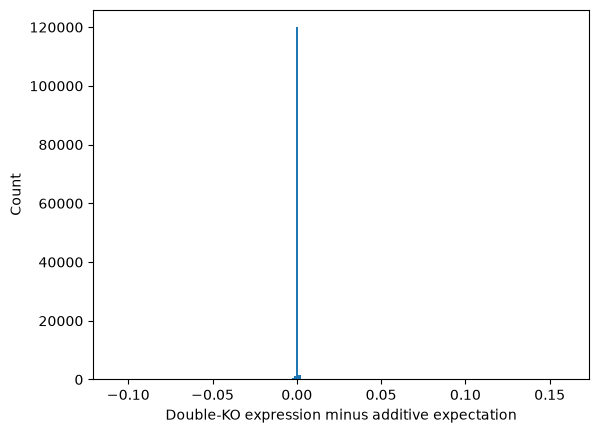

In [37]:
import matplotlib.pyplot as plt

plt.hist(errors, bins=200)
plt.xlabel("Double-KO expression minus additive expectation")
plt.ylabel("Count")
plt.show()

seems like with this setup, there are no nonadditive perturbations
Lets find out if this is due to the selection of perturbations/redout genes
or if this is inherent behavior of the network


In [14]:
from itertools import combinations
from joblib import Parallel, delayed
from pathlib import Path
import numpy as np

# ----------------------------
# Settings
# ----------------------------
N_TARGETS = 100
N_PAIRS = 124
N_JOBS = 4
SEED = 2

rng_module = np.random.default_rng(SEED)

baseline = np.asarray(G.rna).reshape(-1)
single_ko = np.asarray(G.ko)
noise_level = G.s

groups = np.array([G.groups[i] for i in range(G.n)])
module_ids = np.unique(groups)

# ----------------------------
# Find modules with enough
# expressed genes for 100 targets
# ----------------------------
suitable_modules = []

for m in module_ids:
    genes = np.where(groups == m)[0]

    expressed = genes[
        baseline[genes] > noise_level
    ]

    if len(expressed) >= N_TARGETS:
        suitable_modules.append(m)

print("Suitable modules:", suitable_modules)

if len(suitable_modules) == 0:
    raise ValueError(
        "No module contains 100 sufficiently expressed genes."
    )

# Randomly choose one suitable module
module_id = rng_module.choice(suitable_modules)

module_genes = np.where(groups == module_id)[0]

# Only sufficiently expressed genes are used
expressed_module_genes = module_genes[
    baseline[module_genes] > noise_level
]

print("\nSelected module:", module_id)
print("Total genes:", len(module_genes))
print("Expressed genes:", len(expressed_module_genes))

# ----------------------------
# Select perturbation targets
# ----------------------------
targets_module = rng_module.choice(
    expressed_module_genes,
    size=N_TARGETS,
    replace=False
)

# Choose 124 random pairs among them
all_pairs_module = np.array(
    list(combinations(targets_module, 2))
)

pair_indices = rng_module.choice(
    len(all_pairs_module),
    size=N_PAIRS,
    replace=False
)

pairs_module = all_pairs_module[pair_indices]

# ----------------------------
# Readouts:
# ALL sufficiently expressed genes
# from the SAME module
# ----------------------------
readout_genes_module = expressed_module_genes.copy()

print("Targets:", len(targets_module))
print("Pairs:", len(pairs_module))
print("Readout genes:", len(readout_genes_module))

# ----------------------------
# Double-KO simulations
# ----------------------------
def run_double_ko_module(pair):
    a, b = pair

    result = G.ko_nodes(
        [a, b],
        stats=("logfc",)
    )

    return result["logfc"][readout_genes_module]


double_results_module = Parallel(
    n_jobs=N_JOBS,
    verbose=10,
    prefer="processes"
)(
    delayed(run_double_ko_module)(pair)
    for pair in pairs_module
)

double_results_module = np.asarray(double_results_module)

# ----------------------------
# Additive expectation
# ----------------------------
single_a_module = (
    single_ko[pairs_module[:, 0]][:, readout_genes_module]
)

single_b_module = (
    single_ko[pairs_module[:, 1]][:, readout_genes_module]
)

expected_additive_module = (
    single_a_module + single_b_module
)

interaction_residuals_module = (
    double_results_module
    - expected_additive_module
)

errors_module = interaction_residuals_module.ravel()

print()
print(
    "Residual matrix:",
    interaction_residuals_module.shape
)
print(
    "Total interaction tests:",
    errors_module.size
)

# ----------------------------
# Save
# ----------------------------
outdir = Path("results")
outdir.mkdir(exist_ok=True)

save_path = (
    outdir /
    f"grn647_within_module_{module_id}_double_ko.npz"
)

np.savez_compressed(
    save_path,
    module_id=module_id,
    module_genes=module_genes,
    expressed_module_genes=expressed_module_genes,
    targets=targets_module,
    pairs=pairs_module,
    readout_genes=readout_genes_module,
    double_results=double_results_module,
    expected_additive=expected_additive_module,
    interaction_residuals=interaction_residuals_module,
    errors=errors_module
)

print("Saved:", save_path)

Suitable modules: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Selected module: 8
Total genes: 195
Expressed genes: 195
Targets: 100
Pairs: 124
Readout genes: 195


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  3.6min
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  6.8min
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed: 11.2min
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed: 14.4min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed: 18.5min
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed: 23.4min
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed: 28.3min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed: 33.9min
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed: 40.5min
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed: 47.0min
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed: 54.0min
[Parallel(n_jobs=4)]: Done 124 out of 124 | elapsed: 63.5min finished



Residual matrix: (124, 195)
Total interaction tests: 24180
Saved: results/grn647_within_module_8_double_ko.npz


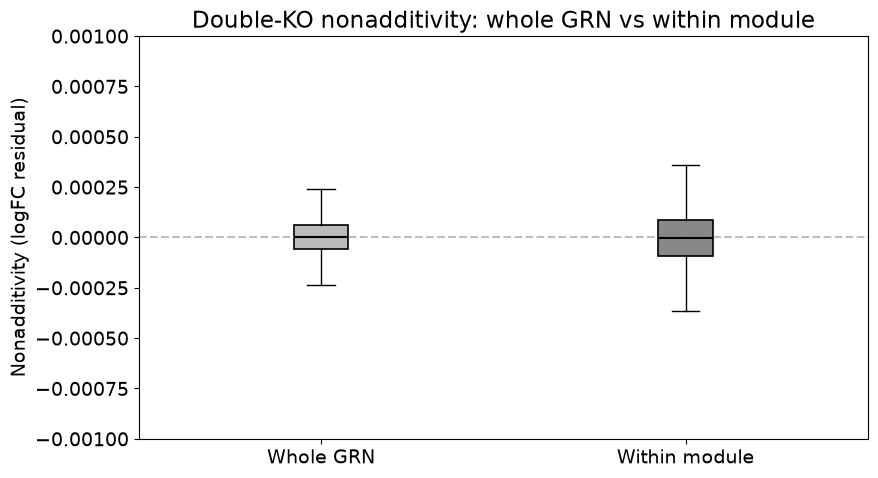

In [15]:

from cycler import cycler
import numpy as np
import matplotlib.pyplot as plt

# Match the style of the other poster figure
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.prop_cycle': cycler(color=['black', '#555555', '#888888', '#bbbbbb']),
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black'
})

# Residuals calculated earlier in this notebook
whole = np.asarray(errors).ravel()
module = np.asarray(errors_module).ravel()

# Exclude non-finite values, if any
whole = whole[np.isfinite(whole)]
module = module[np.isfinite(module)]

plt.figure(figsize=(9, 5))

bp = plt.boxplot(
    [whole, module],
    tick_labels=[
        'Whole GRN',
        'Within module'
    ],
    showfliers=False,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 1.5},
    boxprops={'edgecolor': 'black', 'linewidth': 1.2},
    whiskerprops={'color': 'black'},
    capprops={'color': 'black'}
)

# Grayscale fills consistent with the reference
for box, color in zip(bp['boxes'], ['#bbbbbb', '#888888']):
    box.set_facecolor(color)

plt.ylabel('Nonadditivity (logFC residual)')
plt.title('Double-KO nonadditivity: whole GRN vs within module')

# Zoom to make the central distributions visible
plt.ylim(-0.001, 0.001)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(
    'grn647_whole_vs_module_nonadditivity_boxplot.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


Selected module: 8
Number of readout genes: 195
Number of double KOs: 124
Total residuals: 24180

Mean: 1.617549223063292e-05
SD: 0.009035001844656103
Median: -3.4633024741381746e-06

Quantiles:
 0.000: -0.34237104
 0.001: -0.07953680
 0.010: -0.01024974
 0.050: -0.00062630
 0.500: -0.00000346
 0.950: 0.00069334
 0.990: 0.00954709
 0.999: 0.08934877
 1.000: 0.42790081


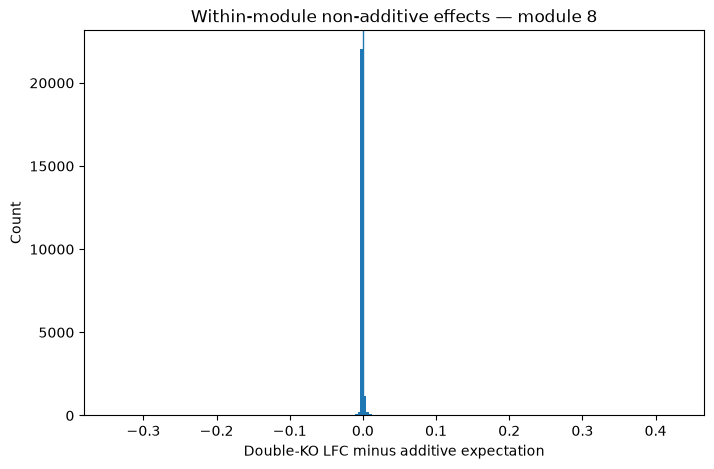

In [41]:
import numpy as np
import matplotlib.pyplot as plt

errors_module = interaction_residuals_module.ravel()

print("Selected module:", module_id)
print("Number of readout genes:", len(readout_genes_module))
print("Number of double KOs:", len(pairs_module))
print("Total residuals:", len(errors_module))

print()
print("Mean:", errors_module.mean())
print("SD:", errors_module.std())
print("Median:", np.median(errors_module))

print()
print("Quantiles:")
qs = [0, 0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999, 1]
for q, value in zip(qs, np.quantile(errors_module, qs)):
    print(f"{q:>6.3f}: {value:.8f}")


# Full histogram
plt.figure(figsize=(8, 5))

plt.hist(
    errors_module,
    bins=200
)

plt.axvline(0, linewidth=1)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title(f"Within-module non-additive effects — module {module_id}")

plt.show()

In [46]:
ls

figures/  GRN#647.ipynb  grn_env.yml  LICENSE  README.md  src/


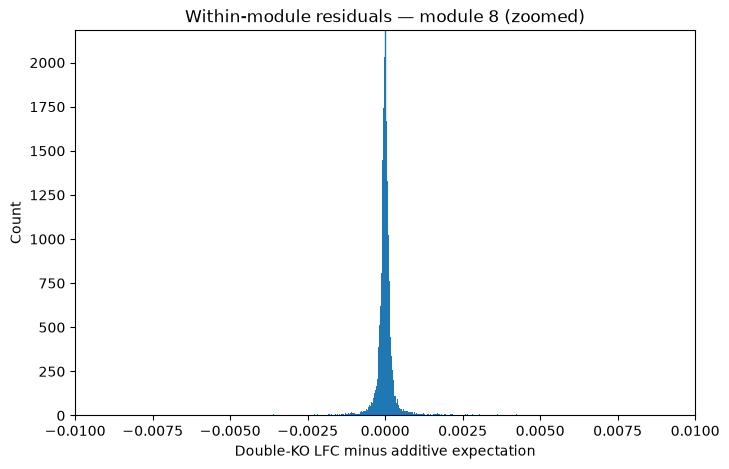

In [48]:
plt.figure(figsize=(8, 5))

plt.hist(
    errors_module,
    bins=30000
)

plt.axvline(0, linewidth=1)

plt.xlim(-0.01, 0.01)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title(f"Within-module residuals — module {module_id} (zoomed)")

plt.show()

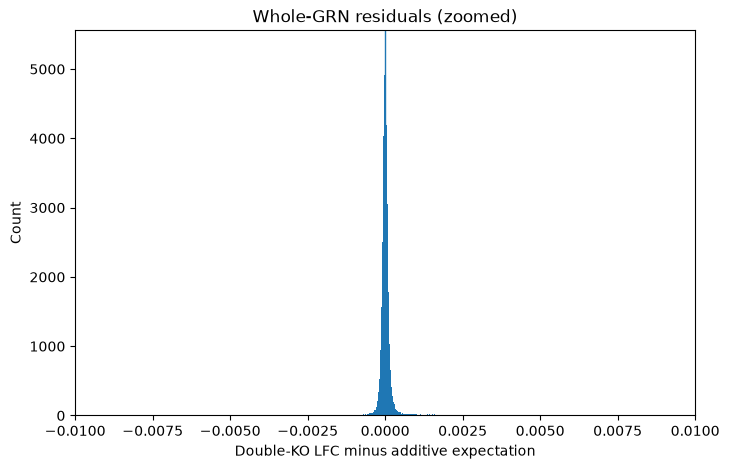

In [51]:
plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30000
)

plt.axvline(0, linewidth=1)

plt.xlim(-0.01, 0.01)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title(f"Whole-GRN residuals (zoomed)")

plt.show()

In [43]:
thresholds = [
    1e-4,
    5e-4,
    1e-3,
    2e-3,
    5e-3,
    1e-2,
    5e-2
]

for threshold in thresholds:
    n = np.sum(np.abs(errors_module) > threshold)

    print(
        f"|residual| > {threshold:g}: "
        f"{n:6d} / {len(errors_module)} "
        f"({100*n/len(errors_module):.3f}%)"
    )

|residual| > 0.0001:  11108 / 24180 (45.939%)
|residual| > 0.0005:   2820 / 24180 (11.663%)
|residual| > 0.001:   1960 / 24180 (8.106%)
|residual| > 0.002:   1413 / 24180 (5.844%)
|residual| > 0.005:    827 / 24180 (3.420%)
|residual| > 0.01:    480 / 24180 (1.985%)
|residual| > 0.05:     96 / 24180 (0.397%)


In [44]:
thresholds = [
    1e-4,
    5e-4,
    1e-3,
    2e-3,
    5e-3,
    1e-2,
    5e-2
]

print(f"{'threshold':>12} {'genome-wide':>15} {'within-module':>15} {'ratio':>10}")

for threshold in thresholds:

    frac_global = np.mean(np.abs(errors) > threshold)
    frac_module = np.mean(np.abs(errors_module) > threshold)

    ratio = frac_module / frac_global if frac_global > 0 else np.inf

    print(
        f"{threshold:12g} "
        f"{100*frac_global:14.3f}% "
        f"{100*frac_module:14.3f}% "
        f"{ratio:9.2f}x"
    )

   threshold     genome-wide   within-module      ratio
      0.0001         29.135%         45.939%      1.58x
      0.0005          4.098%         11.663%      2.85x
       0.001          2.472%          8.106%      3.28x
       0.002          1.030%          5.844%      5.67x
       0.005          0.123%          3.420%     27.90x
        0.01          0.066%          1.985%     30.02x
        0.05          0.012%          0.397%     32.82x


In [52]:
# Genes measured in BOTH experiments
common_readouts = np.intersect1d(
    readout_genes,
    readout_genes_module
)

print("Common readout genes:", len(common_readouts))

# Find their column positions in each result matrix
global_col = {
    gene: i for i, gene in enumerate(readout_genes)
}

module_col = {
    gene: i for i, gene in enumerate(readout_genes_module)
}

global_idx = np.array([
    global_col[g] for g in common_readouts
])

module_idx = np.array([
    module_col[g] for g in common_readouts
])

# Restrict BOTH experiments to exactly the same readout genes
errors_global_matched = (
    interaction_residuals[:, global_idx].ravel()
)

errors_module_matched = (
    interaction_residuals_module[:, module_idx].ravel()
)

thresholds = [
    1e-4,
    5e-4,
    1e-3,
    2e-3,
    5e-3,
    1e-2,
    5e-2
]

print(
    f"{'threshold':>12} "
    f"{'genome-wide':>15} "
    f"{'within-module':>15} "
    f"{'ratio':>10}"
)

for threshold in thresholds:

    global_frac = np.mean(
        np.abs(errors_global_matched) > threshold
    )

    module_frac = np.mean(
        np.abs(errors_module_matched) > threshold
    )

    ratio = module_frac / global_frac

    print(
        f"{threshold:12g} "
        f"{100*global_frac:14.3f}% "
        f"{100*module_frac:14.3f}% "
        f"{ratio:9.2f}x"
    )

Common readout genes: 89
   threshold     genome-wide   within-module      ratio
      0.0001         21.086%         30.518%      1.45x
      0.0005          0.054%          9.451%    173.83x
       0.001          0.009%          7.303%    806.00x
       0.002          0.000%          5.292%       infx
       0.005          0.000%          3.008%       infx
        0.01          0.000%          1.676%       infx
        0.05          0.000%          0.308%       infx


/tmp/ipykernel_487/4271006494.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = module_frac / global_frac


In [53]:
np.savetxt(
    "../results/grn647_global_matched_residuals.txt",
    errors_global_matched
)

np.savetxt(
    "../results/grn647_module_matched_residuals.txt",
    errors_module_matched
)

In [54]:
import numpy as np

# Whole-GRN residual distribution
whole = errors

# Within-module residual distribution
module = errors_module

# Central 95% interval from whole-GRN distribution
lower = np.quantile(whole, 0.025)
upper = np.quantile(whole, 0.975)

print(f"Whole-GRN 95% interval:")
print(f"Lower: {lower:.8f}")
print(f"Upper: {upper:.8f}")

# Check whole-GRN fraction outside
whole_outside = (whole < lower) | (whole > upper)

# Apply SAME limits to within-module values
module_outside = (module < lower) | (module > upper)

print()
print(
    f"Whole-GRN outside interval: "
    f"{whole_outside.sum()} / {len(whole)} "
    f"({100 * whole_outside.mean():.3f}%)"
)

print(
    f"Within-module outside interval: "
    f"{module_outside.sum()} / {len(module)} "
    f"({100 * module_outside.mean():.3f}%)"
)

print()
print(
    f"Enrichment relative to whole-GRN: "
    f"{module_outside.mean() / whole_outside.mean():.2f}x"
)

Whole-GRN 95% interval:
Lower: -0.00031196
Upper: 0.00046369

Whole-GRN outside interval: 6200 / 124000 (5.000%)
Within-module outside interval: 3502 / 24180 (14.483%)

Enrichment relative to whole-GRN: 2.90x


In [ ]:
        
        # compute baseline rna if we need it
        if not hasattr(self, 'rna'):
            self.simulate_rna(save=True, **kwargs)
        
        # do each ko in turn, using the helper function below
        return np.array(Parallel(n_jobs = n_jobs, pre_dispatch = 'n_jobs', prefer='processes'
                                )(delayed(self.ko_one_node)(i) for i in tqdm(range(self.n))))
